# Retail Customer Purchase Pattern Analysis

This notebook performs data analytics on retail customer purchase patterns, including data cleaning, exploratory analysis, and market basket analysis using the Apriori algorithm.

In [13]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import os

# Set style for plots
sns.set(style="whitegrid")
plt.style.use('seaborn-v0_8')

## 2. Load Dataset

Load the retail transaction dataset from a CSV file. We'll use a sample online retail dataset.

In [14]:
# Load the dataset
# For this project, we'll load from a URL. In practice, place the CSV in dataset/ folder.
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)

# Display first few rows
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data Cleaning and Preprocessing

Clean the dataset by removing null values, filtering valid transactions, standardizing product names, and converting dates.

In [15]:
# Data Cleaning
print("Original shape:", df.shape)

# Remove rows with null CustomerID or Description
df = df.dropna(subset=['CustomerID', 'Description'])

# Remove cancelled transactions (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove transactions with negative quantity or zero price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Standardize product descriptions (strip whitespace, uppercase)
df['Description'] = df['Description'].str.strip().str.upper()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Add a TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("After cleaning shape:", df.shape)
df.head()

Original shape: (541909, 8)
After cleaning shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 4. Exploratory Data Analysis

Perform basic analysis: total transactions, unique products, top-selling products, and visualizations.


EXPLORATORY DATA ANALYSIS
Total transactions: 18532
Unique products: 3665
Unique customers: 4338

Top 10 products by quantity:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


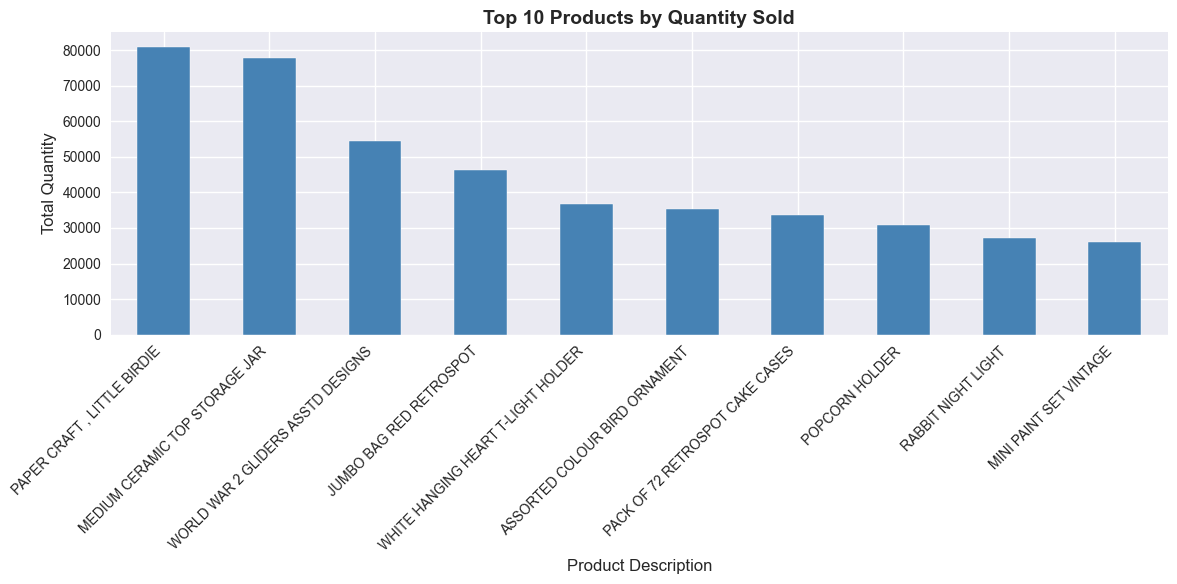

Chart displayed above ↑


In [16]:
# Exploratory Data Analysis
print(f"\n{'='*80}")
print(f"EXPLORATORY DATA ANALYSIS")
print(f"{'='*80}")
print(f"Total transactions: {df['InvoiceNo'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Unique customers: {df['CustomerID'].nunique()}")

# Top-selling products by quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 products by quantity:")
print(top_products)

# Plot top 10 products
plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='steelblue')
plt.title('Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Product Description', fontsize=12)
plt.ylabel('Total Quantity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Chart displayed above ↑")

## 5. Generate Frequency Tables

Create frequency tables for product purchases.

In [17]:
# Frequency table for products
print(f"\n{'='*80}")
print(f"FREQUENCY TABLES")
print(f"{'='*80}")

product_freq = df['Description'].value_counts().head(20)
print("\nTop 20 products by frequency:")
print(product_freq)

# Frequency by country
country_freq = df['Country'].value_counts().head(10)
print("\nTop 10 countries by transaction count:")
print(country_freq)


FREQUENCY TABLES

Top 20 products by frequency:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
PAPER CHAIN KIT 50'S CHRISTMAS        1019
SPOTTY BUNTING                        1017
LUNCH BAG SPACEBOY DESIGN             1008
LUNCH BAG CARS BLUE                    989
HEART OF WICKER SMALL                  985
NATURAL SLATE HEART CHALKBOARD         980
LUNCH BAG PINK POLKADOT                957
REX CASH+CARRY JUMBO SHOPPER           952
LUNCH BAG SUKI DESIGN                  933
ALARM CLOCK BAKELIKE RED               899
Name: count, dtype: int64

Top 10 countries by transaction count:
Country
Unite

## 6. Market Basket Analysis

Perform market basket analysis using the Apriori algorithm to find frequent itemsets and association rules.

In [18]:
# Prepare data for market basket analysis
# Group by InvoiceNo to get baskets
basket = df.groupby('InvoiceNo')['Description'].apply(list).reset_index()

# Convert to transaction list
transactions = basket['Description'].tolist()

# Use TransactionEncoder to convert to binary matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Basket shape: {basket_df.shape}")
basket_df.head()

Basket shape: (18532, 3866)


,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
# Find frequent itemsets with Apriori
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("Frequent itemsets (min support 0.01):")
print(frequent_itemsets.head(10))

Frequent itemsets (min support 0.01):
      support                                         itemsets
587  0.106357  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
413  0.091895            frozenset({REGENCY CAKESTAND 3 TIER})
246  0.086337             frozenset({JUMBO BAG RED RETROSPOT})
337  0.074412                       frozenset({PARTY BUNTING})
37   0.074196       frozenset({ASSORTED COLOUR BIRD ORNAMENT})
281  0.069501             frozenset({LUNCH BAG RED RETROSPOT})
468  0.061839    frozenset({SET OF 3 CAKE TINS PANTRY DESIGN})
373  0.059303                             frozenset({POSTAGE})
273  0.056767             frozenset({LUNCH BAG  BLACK SKULL.})
322  0.055526     frozenset({PACK OF 72 RETROSPOT CAKE CASES})


In [20]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values(by='lift', ascending=False)

print("Association rules (min confidence 0.5):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Association rules (min confidence 0.5):
                                           antecedents  \
216                frozenset({REGENCY TEA PLATE PINK})   
215               frozenset({REGENCY TEA PLATE GREEN})   
271          frozenset({POPPY'S PLAYHOUSE LIVINGROOM})   
266  frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...   
203                 frozenset({REGENCY MILK JUG PINK})   
202              frozenset({REGENCY SUGAR BOWL GREEN})   
270             frozenset({POPPY'S PLAYHOUSE BEDROOM})   
267  frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...   
231               frozenset({REGENCY TEA PLATE ROSES})   
232                frozenset({REGENCY TEA PLATE PINK})   

                                           consequents   support  confidence  \
216               frozenset({REGENCY TEA PLATE GREEN})  0.010900    0.901786   
215                frozenset({REGENCY TEA PLATE PINK})  0.010900    0.748148   
271  frozenset({POPPY'S PLAYHOUSE KITCHEN, POPPY'S ...  0.010037    0.738095   
2

## 7. Visualization

Create visualizations: top 10 products bar chart, heatmap of associations, scatter plot of support vs confidence.


VISUALIZATION: SUPPORT VS CONFIDENCE


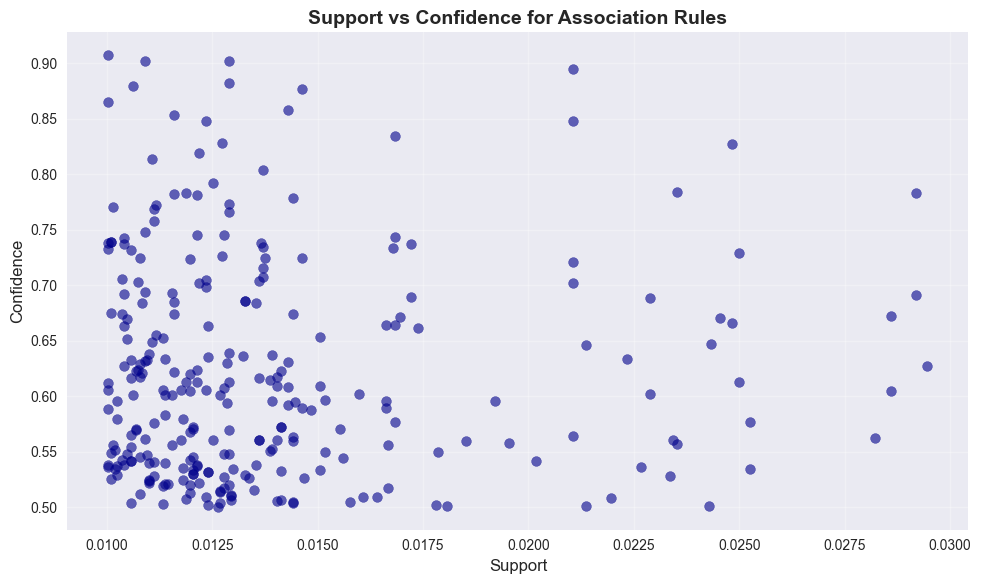

Chart displayed above ↑

TOP 10 ASSOCIATION RULES BY LIFT


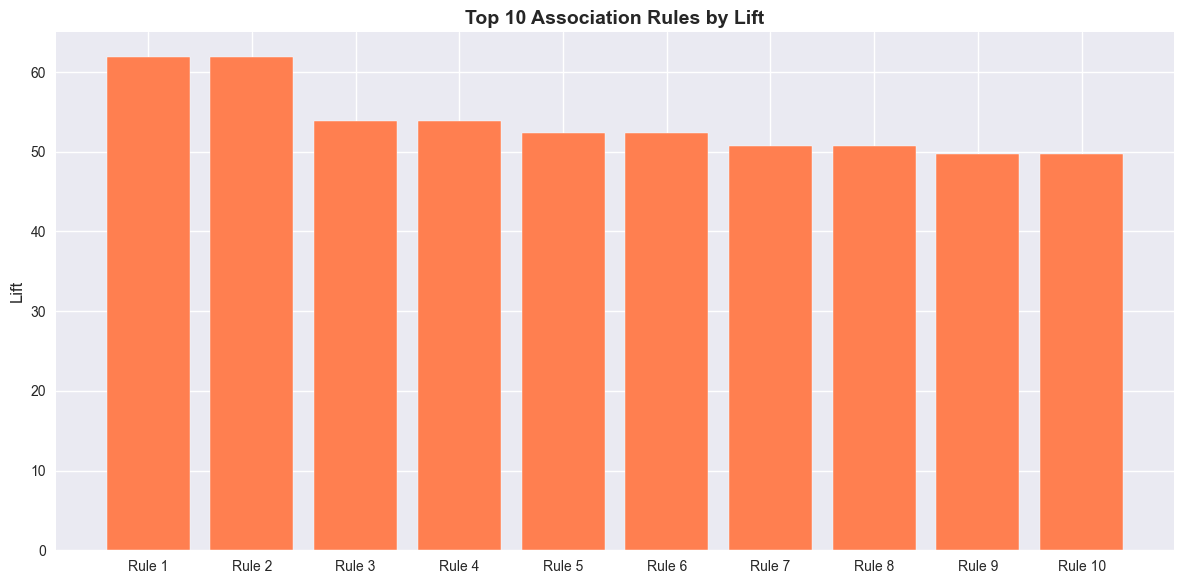

Chart displayed above ↑


In [21]:
# Scatter plot of support vs confidence
print(f"\n{'='*80}")
print(f"VISUALIZATION: SUPPORT VS CONFIDENCE")
print(f"{'='*80}")
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.6, s=50, color='darkblue')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Support vs Confidence for Association Rules', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Chart displayed above ↑")

# Bar plot of lift for top rules
print(f"\n{'='*80}")
print(f"TOP 10 ASSOCIATION RULES BY LIFT")
print(f"{'='*80}")
top_rules = rules.head(10)
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_rules)), top_rules['lift'], color='coral')
plt.xticks(range(len(top_rules)), [f"Rule {i+1}" for i in range(len(top_rules))], rotation=0)
plt.title('Top 10 Association Rules by Lift', fontsize=14, fontweight='bold')
plt.ylabel('Lift', fontsize=12)
plt.tight_layout()
plt.show()
print("Chart displayed above ↑")

## 8. Save Outputs

Save association rules to CSV and ensure charts are saved.

In [22]:
# Display Association Rules Summary
print(f"\n{'='*80}")
print(f"ASSOCIATION RULES SUMMARY")
print(f"{'='*80}")
print(f"Total Association Rules Generated: {len(rules)}")
print(f"\nTop 10 Rules by Lift:")
print("-" * 80)

for idx, (_, row) in enumerate(rules.head(10).iterrows(), 1):
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"\nRule {idx}:")
    print(f"  If customer buys: {antecedents}")
    print(f"  Then likely buys: {consequents}")
    print(f"  Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")

print(f"\n{'='*80}")
print(f"ANALYSIS COMPLETE!")
print(f"{'='*80}")
print(f"\nAll outputs displayed above ↑")


ASSOCIATION RULES SUMMARY
Total Association Rules Generated: 275

Top 10 Rules by Lift:
--------------------------------------------------------------------------------

Rule 1:
  If customer buys: REGENCY TEA PLATE PINK
  Then likely buys: REGENCY TEA PLATE GREEN
  Support: 0.0109 | Confidence: 0.9018 | Lift: 61.8959

Rule 2:
  If customer buys: REGENCY TEA PLATE GREEN
  Then likely buys: REGENCY TEA PLATE PINK
  Support: 0.0109 | Confidence: 0.7481 | Lift: 61.8959

Rule 3:
  If customer buys: POPPY'S PLAYHOUSE LIVINGROOM
  Then likely buys: POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE BEDROOM
  Support: 0.0100 | Confidence: 0.7381 | Lift: 53.8519

Rule 4:
  If customer buys: POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE BEDROOM
  Then likely buys: POPPY'S PLAYHOUSE LIVINGROOM
  Support: 0.0100 | Confidence: 0.7323 | Lift: 53.8519

Rule 5:
  If customer buys: REGENCY MILK JUG PINK
  Then likely buys: REGENCY SUGAR BOWL GREEN
  Support: 0.0111 | Confidence: 0.7574 | Lift: 52.3704

Rule